In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
datosGeneracion = pd.read_csv(r"/home/ernesto/trabajo/Datasets/datos/solar/Plant_1_Generation_Data.csv")
datosMeteorologia = pd.read_csv(r"/home/ernesto/trabajo/Datasets/datos/solar/Plant_1_Weather_Sensor_Data.csv")


Una vez cargadas, visualizamos la info de los dos csv para poder juntarlos

In [30]:
print(datosGeneracion.info())
print(datosMeteorologia.info())

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION 

En primer lugar transformamos todas las fechas a formato DATE_TIME

In [31]:
datosGeneracion['DATE_TIME'] = pd.to_datetime(datosGeneracion['DATE_TIME'])
datosMeteorologia['DATE_TIME'] = pd.to_datetime(datosMeteorologia['DATE_TIME'])

/tmp/ipykernel_9916/3995665072.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  datosGeneracion['DATE_TIME'] = pd.to_datetime(datosGeneracion['DATE_TIME'])


Luego cruzamos las tablas

In [32]:
datosUnidos= pd.merge(datosMeteorologia,datosGeneracion,on='DATE_TIME',how = 'inner')
datosUnidos = datosUnidos.sort_values(by=['SOURCE_KEY_y', 'DATE_TIME'])
datosUnidos = datosUnidos.set_index('DATE_TIME')
print(datosUnidos.shape)
print(datosMeteorologia.shape)


(68774, 11)
(3182, 6)


Eliminamos una de las columnas de id de las plantas al estar duplicadas

In [33]:
datosUnidos = datosUnidos.drop(columns=['PLANT_ID_x'])


En primer lugar hacemos una funcion para detectar outliers y mediante una interpolación temporal hacemos que los NaN se rellenen automáticamente

In [34]:
def fueraRango(valor, min_val, max_val):
    if valor < min_val or valor > max_val:
        return np.nan
    return valor
        
datosUnidos['DC_POWER'] = datosUnidos['DC_POWER'].apply(
    fueraRango, 
    min_val=0, 
    max_val=15000
)
datosUnidos['DC_POWER'] = datosUnidos.groupby('SOURCE_KEY_y')['DC_POWER'].transform(
    lambda x: x.interpolate(method='time')
)

Contamos cuantas mediciones se han hecho por hora

In [35]:
datosUnidos['TRAMO_HORARIO'] = datosUnidos.index.floor('h') 
ranking_tramos = datosUnidos['TRAMO_HORARIO'].value_counts().reset_index(name='frecuencia')
print(ranking_tramos)

          TRAMO_HORARIO  frecuencia
0   2020-05-15 07:00:00          88
1   2020-05-15 08:00:00          88
2   2020-05-15 09:00:00          88
3   2020-05-15 10:00:00          88
4   2020-05-15 11:00:00          88
..                  ...         ...
791 2020-06-04 19:00:00          40
792 2020-05-15 23:00:00          22
793 2020-05-21 07:00:00          22
794 2020-05-23 05:00:00          22
795 2020-05-23 06:00:00          22

[796 rows x 2 columns]


Buscamos las que más y menos generan

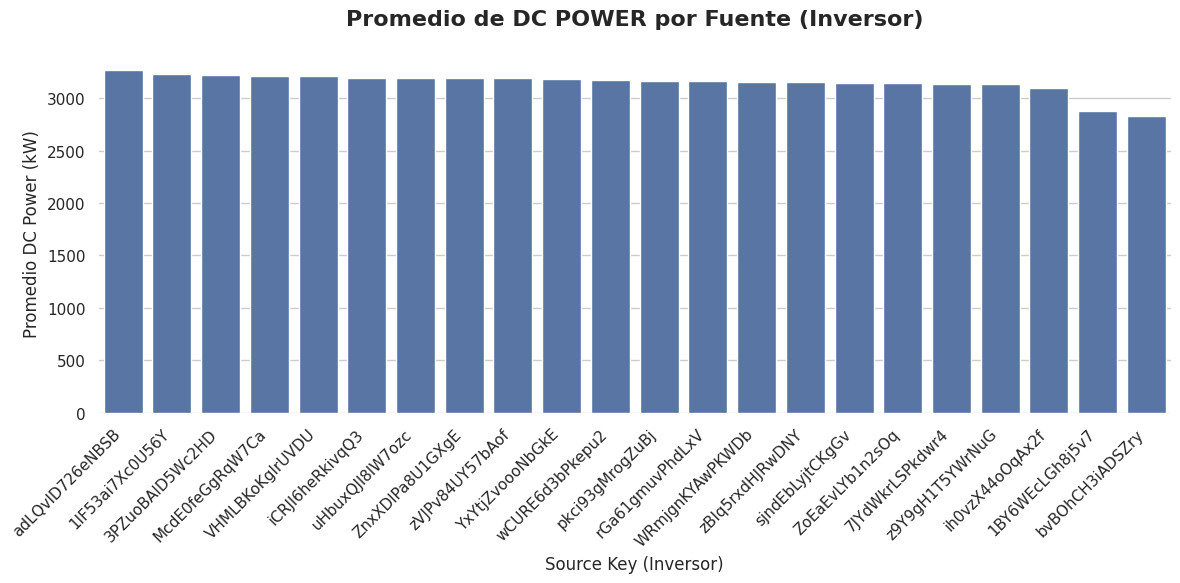

In [36]:

dU_promedio = datosUnidos.groupby('SOURCE_KEY_y')['DC_POWER'].mean().sort_values(ascending=False).reset_index()
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))
plot = sns.barplot(
    data=dU_promedio, 
    x='SOURCE_KEY_y', 
    y='DC_POWER', 
)
plt.title('Promedio de DC POWER por Fuente (Inversor)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Source Key (Inversor)', fontsize=12)
plt.ylabel('Promedio DC Power (kW)', fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine(left=True, bottom=True)

plt.tight_layout() 
plt.show()

Ahora vamos a ver la relación entre la producción y la irradiación solar. Como nota debemos subrayar que los datos "extraños" que observamos en el eje vertical izquierdo del gráfico de disperión en los que la radiación solar es mayor a 0 pero no se genera potencia no se han eliminado al ser muy útiles para encontrar fallos operativos en los inversores

La correlación entre las dos variables es de 0.9893910408878281 lo que indica alta correlación


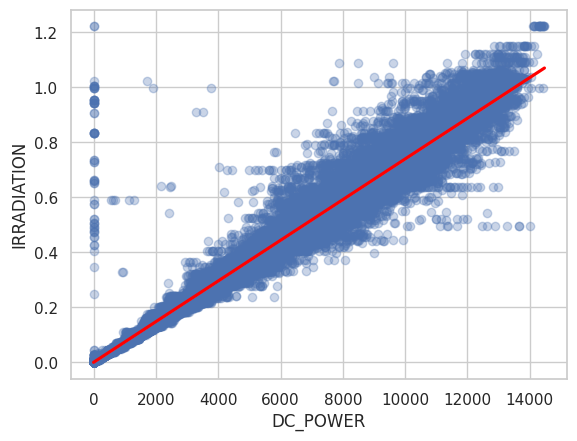

In [37]:
correlacionIrradiacion = datosUnidos['DC_POWER'].corr(datosUnidos['IRRADIATION'])
sns.regplot(data=datosUnidos,x='DC_POWER',y= 'IRRADIATION',scatter_kws={'alpha':0.3},line_kws={'color':'red'})
print (f"La correlación entre las dos variables es de {correlacionIrradiacion} lo que indica alta correlación")

¿Qué es más importante para la generación, la temperatura del modulo, la ambiente o la irradiación?

Irradiación : 0.9894
Temp. Módulo : 0.9548
Temp. Ambiente : 0.7247


<Axes: xlabel='COEFICIENTE', ylabel='VARIABLE'>

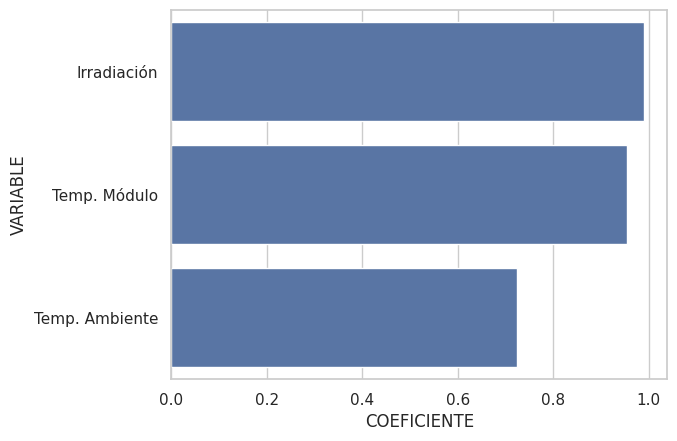

In [38]:
correlacionTempAmb = datosUnidos['DC_POWER'].corr(datosUnidos['AMBIENT_TEMPERATURE'])
corrrelacionTempMod = datosUnidos['DC_POWER'].corr(datosUnidos['MODULE_TEMPERATURE'])

lista_corr = [
    ("Irradiación", correlacionIrradiacion),
    ("Temp. Ambiente", correlacionTempAmb),
    ("Temp. Módulo", corrrelacionTempMod)
]

lista_corr.sort(key=lambda x: x[1], reverse=True)

for nombre, valor in lista_corr:
    print(f"{nombre} : {valor:.4f}")
df_LCorr = pd.DataFrame(lista_corr,columns=['VARIABLE','COEFICIENTE'])
sns.barplot(data=df_LCorr,x='COEFICIENTE',y='VARIABLE')

Sabiendo ya la importancia de la irradiación, buscaremos las horas donde teóricamente obtendremos más generación

La irradiación máxima promedio es de  0.7618450223333333 y se da a las 12.0


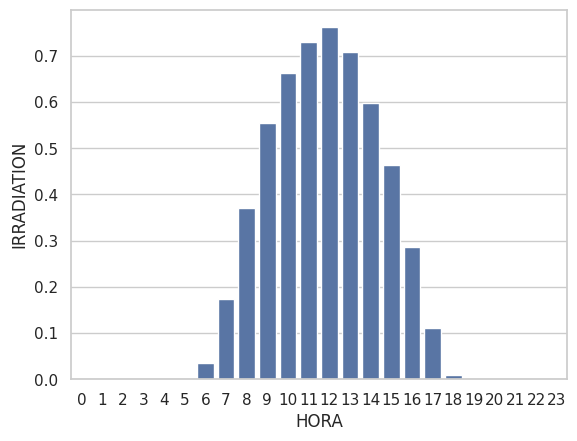

In [39]:
datosUnidos['HORA']= datosUnidos.index.hour
irrHora = datosUnidos.groupby('HORA')['IRRADIATION'].median().reset_index()
sns.barplot(data=irrHora,x= 'HORA', y = 'IRRADIATION')
indice_max_irr = irrHora['IRRADIATION'].idxmax()
fila_maxima = irrHora.loc[indice_max_irr]
print(f"La irradiación máxima promedio es de  {fila_maxima['IRRADIATION']} y se da a las {fila_maxima['HORA']}")

Desde la empresa nos comunican que ha bajado la potencia mucho en los últimos meses, seguramente provocado por el deterioro o fallo de alguno de los inversores, nos piden localizar los inversores defectuosos para poder repararlos.

Usaremos un ratio de rendimiento calculado sobre la radiación solar para identificar los outliers a la baja que son los que están causando este fallo

In [40]:
# Creamos el resumen por inversor
irrDCComb = datosUnidos.groupby('SOURCE_KEY_y').agg({
    'DC_POWER': 'mean',
    'IRRADIATION': 'mean'
}).reset_index()

irrDCComb['RATIOPROD'] = irrDCComb['DC_POWER'] / irrDCComb['IRRADIATION']
mediana = abs(irrDCComb['RATIOPROD'].median())
Q1 = irrDCComb['RATIOPROD'].quantile(0.25)
Q3 = irrDCComb['RATIOPROD'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
inversores_fallando = irrDCComb[irrDCComb['RATIOPROD'] < limite_inferior]
ids_defectuosos = inversores_fallando['SOURCE_KEY_y'].tolist()
print(f"Inversores defectuosos \n {inversores_fallando}")
print(f"La mediana de ratio es de {mediana}")

Inversores defectuosos 
        SOURCE_KEY_y     DC_POWER  IRRADIATION     RATIOPROD
0   1BY6WEcLGh8j5v7  2873.720981     0.230310  12477.635115
11  bvBOhCH3iADSZry  2828.998291     0.230245  12286.930193
La mediana de ratio es de 13613.39090172688


La empresa desea conocer si la restauración de estas plantas sería óptimo o, si en cambio el restaurarlas resultaria en una pérdida de dinero. Para ello nos han pedido una simulación de la generación si se restauran las plantas, sobretodo inquiriendo en que debe ser expuesta de forma muy visual.

In [42]:

datosUnidos_ml = datosUnidos.dropna(subset=['AMBIENT_TEMPERATURE', 'IRRADIATION', 'DC_POWER'])  
datos_entrenamiento = datosUnidos_ml[~datosUnidos_ml['SOURCE_KEY_y'].isin(ids_defectuosos)]
X = datos_entrenamiento[['AMBIENT_TEMPERATURE','IRRADIATION']]
y = datos_entrenamiento['DC_POWER']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
modelo_inversor = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_inversor.fit(X_train, y_train)
error = mean_absolute_error(y_test, predicciones)
print(f"El error medio de mi Gemelo Digital es de: {error:.2f} kW")




NameError: name 'train_test_split' is not defined

Ahora aplicamos el GD y estimamos la potencia generada

In [ ]:
datos_test = datosUnidos.loc[
    datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 
    ['SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'IRRADIATION']
].dropna()
Kw_restauracion = modelo_inversor.predict(
    datos_test[['AMBIENT_TEMPERATURE', 'IRRADIATION']]
)
datos_test['DC_POWER_TEORICO'] = Kw_restauracion

# 3. Prints Corregidos
print("--- Media Teórica por Inversor Defectuoso ---")
print(datos_test.groupby('SOURCE_KEY_y')['DC_POWER_TEORICO'].mean())

print("\n--- Media Real de Toda la Planta (Referencia) ---")
print(datosUnidos['DC_POWER'].mean())

--- Media Teórica por Inversor Defectuoso ---
SOURCE_KEY_y
1BY6WEcLGh8j5v7    3148.758223
bvBOhCH3iADSZry    3147.800920
Name: DC_POWER_TEORICO, dtype: float64

--- Media Real de Toda la Planta (Referencia) ---
3147.1774501376403


Ahora lo representamos para los stake holders

/tmp/ipykernel_36648/4240167064.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estado', y='Potencia (kW)', data=datos_grafico, palette=['red', 'gray', 'green'])


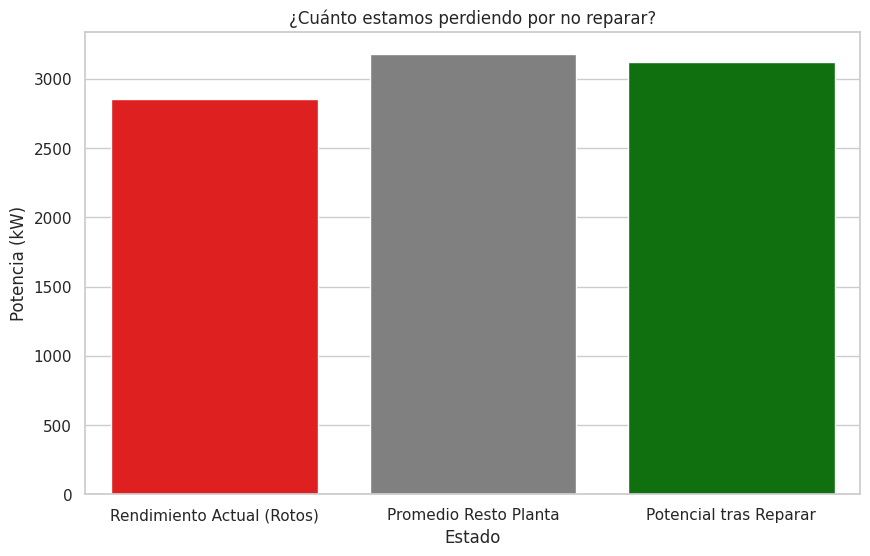

In [ ]:
# 1. Calculamos las tres medias principales
media_plant_sana = datosUnidos.loc[~datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 'DC_POWER'].mean()
media_actual_defectuosos = datosUnidos.loc[datosUnidos['SOURCE_KEY_y'].isin(ids_defectuosos), 'DC_POWER'].mean()
media_potencial_defectuosos = datos_test['DC_POWER_TEORICO'].mean()

# 2. Creamos una tablita rápida para graficar
datos_grafico = {
    'Estado': ['Rendimiento Actual (Rotos)', 'Promedio Resto Planta', 'Potencial tras Reparar'],
    'Potencia (kW)': [media_actual_defectuosos, media_plant_sana, media_potencial_defectuosos]
}

# 3. Dibujamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Estado', y='Potencia (kW)', data=datos_grafico, palette=['red', 'gray', 'green'])
plt.title('¿Cuánto estamos perdiendo por no reparar?')
plt.show()